# SHAP Analysis on Models' Results

SHAP analysis is used to explain which features drive early diabetes risk predictions and how they influence outcomes (positively or negatively). It also enables comparison across XGBoost, Random Forest, and Logistic Regression to assess consistency in feature importance. Overall, it improves interpretability and trust in the models’ decisions.

The three models selected for SHAP analysis are **XGBoost + SMOTE-ENN** (AUC-ROC = 0.8198), **Logistic Regression + SMOTE-ENN** (AUC-ROC = 0.8176), and **Random Forest + SMOTE-ENN** (AUC-ROC = 0.8072). Each represents the best-performing variant within its model family. All three also achieved strong F1 scores between 0.45–0.48 (notable given the heavy class imbalance, where a naïve majority-class classifier would yield an F1 of 0 for the minority class).

## XGBoost + SMOTE-ENN

### Data loading, balancing, and retraining:

In [17]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN
from sklearn.metrics import classification_report, roc_auc_score
import shap

# Load data
X_train = np.load('data/X_train.npy')
X_test = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test = np.load('data/y_test.npy')
feature_names = pd.read_csv('data/feature_names.csv').values.flatten()

# Apply SMOTE-ENN
X_train_smoteenn, y_train_smoteenn = SMOTEENN(random_state=42).fit_resample(X_train, y_train)

# Retrain XGBoost (same hyperparameters as 02_modeling)
xgb_smoteenn = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_smoteenn.fit(X_train_smoteenn, y_train_smoteenn)
xgb_smoteenn_pred = xgb_smoteenn.predict(X_test)

print("XGBoost - SMOTE-ENN Results:\n")
print(classification_report(y_test, xgb_smoteenn_pred, target_names=['No Diabetes', 'Diabetes']))
print("AUC-ROC:", round(roc_auc_score(y_test, xgb_smoteenn.predict_proba(X_test)[:,1]), 4))

XGBoost - SMOTE-ENN Results:

              precision    recall  f1-score   support

 No Diabetes       0.93      0.79      0.85     42741
    Diabetes       0.38      0.68      0.48      7995

    accuracy                           0.77     50736
   macro avg       0.65      0.73      0.67     50736
weighted avg       0.84      0.77      0.80     50736

AUC-ROC: 0.8198


### SHAP values

In [18]:
# TreeExplainer is exact and fast for tree-based models
explainer = shap.TreeExplainer(xgb_smoteenn)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test_df)

print("SHAP values computed")
print(f"Shape: {shap_values.shape} (samples x features)")
print(f"Expected value (base rate): {round(explainer.expected_value, 4)}")

SHAP values computed
Shape: (50736, 21) (samples x features)
Expected value (base rate): 0.667900025844574


### Summary bar plot (global feature importance)

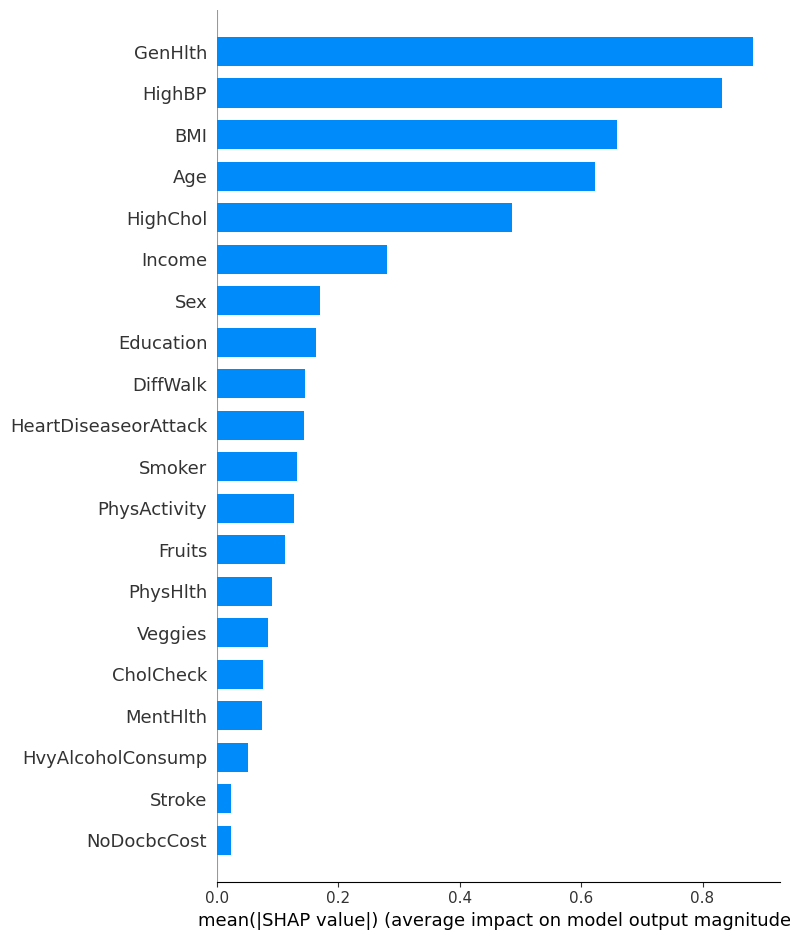

In [19]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=True)

### Beeswarm plot (direction + magnitude per feature):

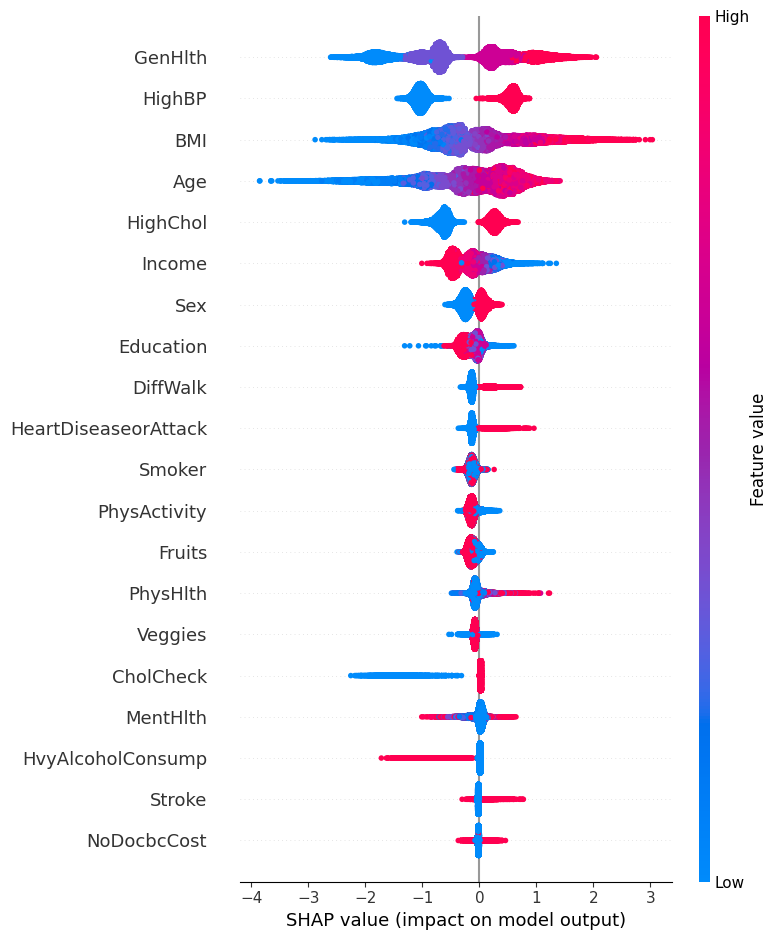

In [20]:
shap.summary_plot(shap_values, X_test_df, show=True)

The bar plot shows that GenHlth, HighBP, BMI, Age, and HighChol are the top five most influential features, with GenHlth and HighBP dominating by a clear margin. The remaining features contribute relatively little individually. The beeswarm plot reveals the direction of these effects: worse general health, having high blood pressure, higher BMI, older age, and high cholesterol all push the model toward predicting diabetes (red dots right of center). Notably, Income shows a protective pattern where higher income is associated with lower predicted risk, likely reflecting access to healthcare and healthier lifestyles. Features like Stroke, NoDocbcCost, and HvyAlcoholConsump have minimal impact on this model's predictions.

## Random Forest + SMOTE-ENN 

### Train & verify:

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_smoteenn = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=12)
rf_smoteenn.fit(X_train_smoteenn, y_train_smoteenn)
rf_smoteenn_pred = rf_smoteenn.predict(X_test)

print("Random Forest - SMOTE-ENN Results:\n")
print(classification_report(y_test, rf_smoteenn_pred, target_names=['No Diabetes', 'Diabetes']))
print("AUC-ROC:", round(roc_auc_score(y_test, rf_smoteenn.predict_proba(X_test)[:,1]), 4))

Random Forest - SMOTE-ENN Results:

              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     42741
    Diabetes       0.33      0.77      0.47      7995

    accuracy                           0.72     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.85      0.72      0.76     50736

AUC-ROC: 0.818


### SHAP values:

In [29]:
explainer_rf = shap.TreeExplainer(rf_smoteenn)
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_sample = X_test_df.sample(n=5000, random_state=42)
shap_values_rf = explainer_rf.shap_values(X_test_sample)
shap_values_rf = shap_values_rf[:, :, 1]

print("SHAP values computed!")
print(f"Shape: {shap_values_rf.shape}")
print(f"Expected value (base rate): {round(explainer_rf.expected_value[1], 4)}")

SHAP values computed!
Shape: (5000, 21)
Expected value (base rate): 0.618


### Bar plot:

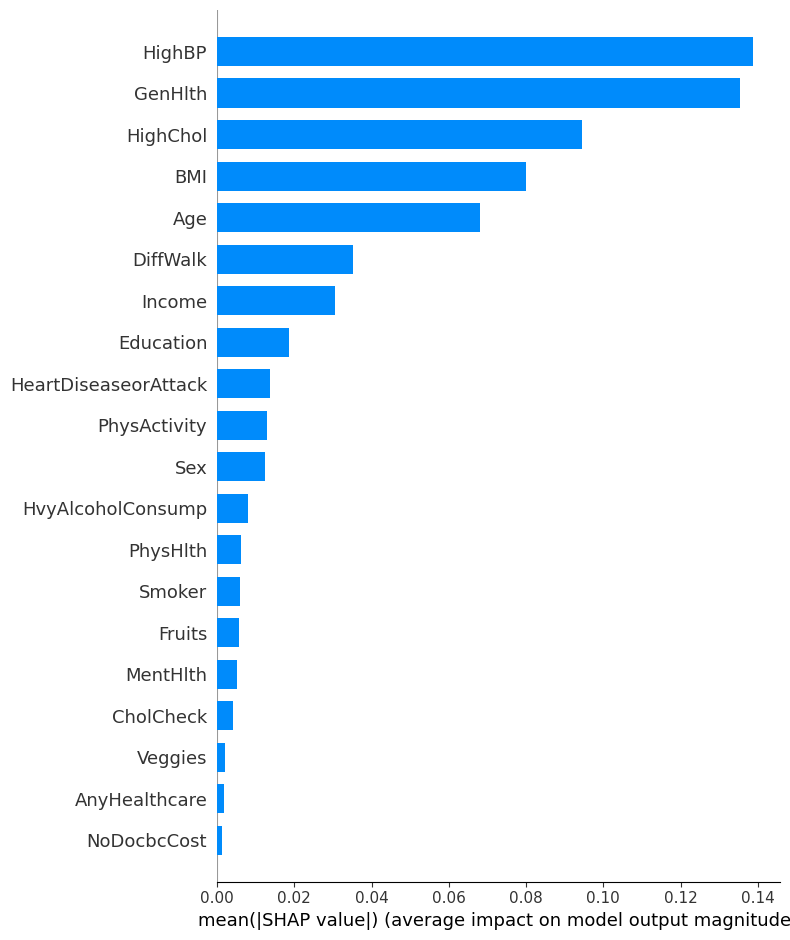

In [31]:
shap.summary_plot(shap_values_rf, X_test_sample, plot_type="bar", show=True)

### Beeswarm plot:

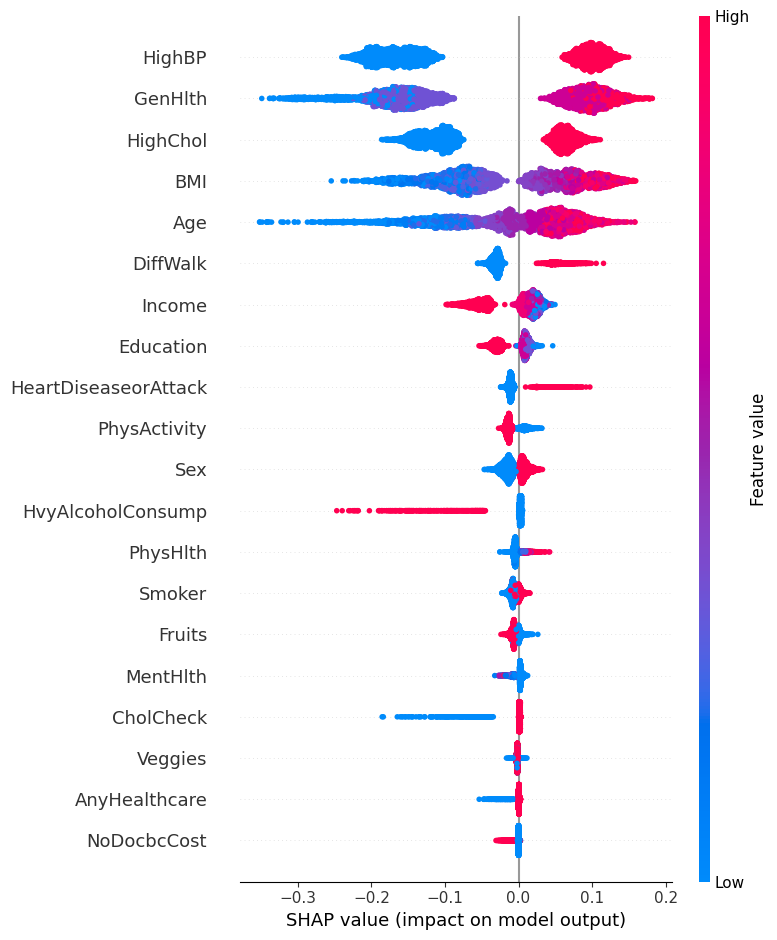

In [32]:
shap.summary_plot(shap_values_rf, X_test_sample, show=True)

The bar plot shows **HighBP and GenHlth** as the two most influential features, nearly tied, followed closely by **HighChol, BMI, and Age** — the same top five as XGBoost but in a slightly different order. A notable difference is that **DiffWalk** ranks 6th here, higher than in XGBoost, suggesting the Random Forest relies more on mobility difficulty as a diabetes signal. The beeswarm plot confirms the expected directions: high blood pressure, worse general health, high cholesterol, higher BMI, and older age all push predictions toward diabetes. HvyAlcoholConsump shows an interesting pattern where high values pull strongly away from diabetes risk. The bottom features (Veggies, AnyHealthcare, NoDocbcCost) contribute almost nothing to the model's decisions.

## Logistic Regression + SMOTE-ENN — SHAP Analysis

### Balance scaled data & train:

In [33]:
from sklearn.linear_model import LogisticRegression

X_train_scaled = np.load('data/X_train_scaled.npy')
X_test_scaled = np.load('data/X_test_scaled.npy')

X_train_smoteenn_scaled, y_train_smoteenn_scaled = SMOTEENN(random_state=42).fit_resample(X_train_scaled, y_train)

lr_smoteenn = LogisticRegression(max_iter=1000, random_state=42)
lr_smoteenn.fit(X_train_smoteenn_scaled, y_train_smoteenn_scaled)
lr_smoteenn_pred = lr_smoteenn.predict(X_test_scaled)

print("Logistic Regression - SMOTE-ENN Results:\n")
print(classification_report(y_test, lr_smoteenn_pred, target_names=['No Diabetes', 'Diabetes']))
print("AUC-ROC:", round(roc_auc_score(y_test, lr_smoteenn.predict_proba(X_test_scaled)[:,1]), 4))

Logistic Regression - SMOTE-ENN Results:

              precision    recall  f1-score   support

 No Diabetes       0.96      0.64      0.77     42741
    Diabetes       0.30      0.84      0.45      7995

    accuracy                           0.67     50736
   macro avg       0.63      0.74      0.61     50736
weighted avg       0.85      0.67      0.71     50736

AUC-ROC: 0.8176


### SHAP values:

In [34]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

explainer_lr = shap.LinearExplainer(lr_smoteenn, X_train_smoteenn_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled_df)

print("SHAP values computed")
print(f"Shape: {shap_values_lr.shape}")
print(f"Expected value (base rate): {round(explainer_lr.expected_value, 4)}")

SHAP values computed
Shape: (50736, 21)
Expected value (base rate): 0.7171


### Bar plot

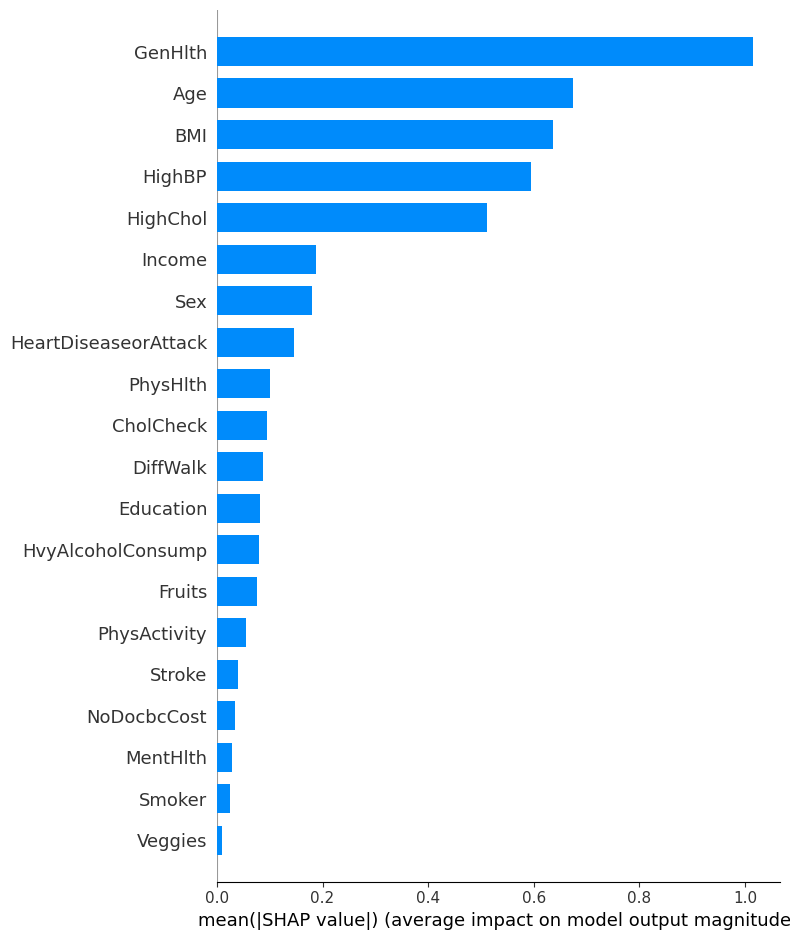

In [35]:
shap.summary_plot(shap_values_lr, X_test_scaled_df, plot_type="bar", show=True)

### Beeswarm plot:

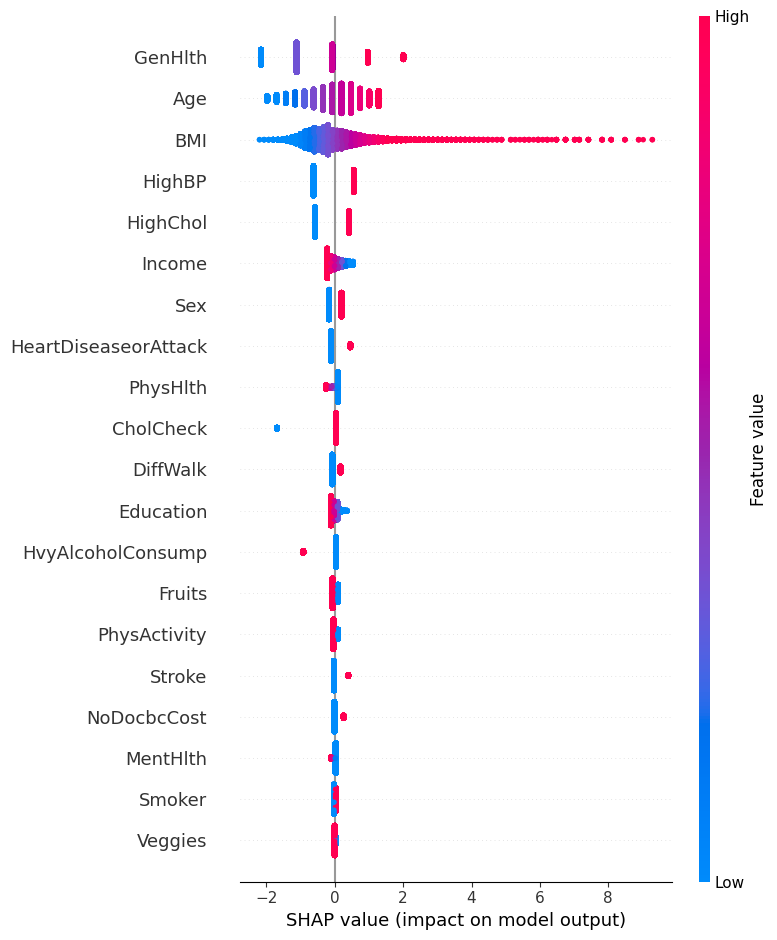

In [36]:
shap.summary_plot(shap_values_lr, X_test_scaled_df, show=True)

## Interpretation of SHAP Results Across All Three Models


### Raw Result Values:

In [37]:
from IPython.display import display, Markdown

# === TABLE 1: Feature Importance (Mean |SHAP|) ===
shap_comparison = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': np.abs(shap_values).mean(axis=0),
    'Random Forest': np.abs(shap_values_rf).mean(axis=0),
    'Logistic Regression': np.abs(shap_values_lr).mean(axis=0)
})

shap_comparison['Average'] = shap_comparison[['XGBoost', 'Random Forest', 'Logistic Regression']].mean(axis=1)
shap_comparison = shap_comparison.sort_values('Average', ascending=False).reset_index(drop=True)
shap_comparison['XGB Rank'] = shap_comparison['XGBoost'].rank(ascending=False).astype(int)
shap_comparison['RF Rank'] = shap_comparison['Random Forest'].rank(ascending=False).astype(int)
shap_comparison['LR Rank'] = shap_comparison['Logistic Regression'].rank(ascending=False).astype(int)

table1 = "| Feature | XGBoost | RF | LR | Average | XGB Rank | RF Rank | LR Rank |\n"
table1 += "|---|---|---|---|---|---|---|---|\n"
for _, row in shap_comparison.iterrows():
    table1 += f"| {row['Feature']} | {row['XGBoost']:.4f} | {row['Random Forest']:.4f} | {row['Logistic Regression']:.4f} | {row['Average']:.4f} | {row['XGB Rank']} | {row['RF Rank']} | {row['LR Rank']} |\n"

display(Markdown("### Feature Importance (Mean |SHAP|)\n" + table1))

### Feature Importance (Mean |SHAP|)
| Feature | XGBoost | RF | LR | Average | XGB Rank | RF Rank | LR Rank |
|---|---|---|---|---|---|---|---|
| GenHlth | 0.8835 | 0.1355 | 1.0157 | 0.6782 | 1 | 2 | 1 |
| HighBP | 0.8325 | 0.1388 | 0.5945 | 0.5219 | 2 | 1 | 4 |
| BMI | 0.6590 | 0.0799 | 0.6356 | 0.4582 | 3 | 4 | 3 |
| Age | 0.6224 | 0.0681 | 0.6737 | 0.4548 | 4 | 5 | 2 |
| HighChol | 0.4868 | 0.0944 | 0.5122 | 0.3645 | 5 | 3 | 5 |
| Income | 0.2801 | 0.0305 | 0.1870 | 0.1658 | 6 | 7 | 6 |
| Sex | 0.1699 | 0.0126 | 0.1808 | 0.1211 | 7 | 11 | 7 |
| HeartDiseaseorAttack | 0.1440 | 0.0137 | 0.1460 | 0.1012 | 10 | 9 | 8 |
| DiffWalk | 0.1458 | 0.0353 | 0.0880 | 0.0897 | 9 | 6 | 11 |
| Education | 0.1627 | 0.0188 | 0.0816 | 0.0877 | 8 | 8 | 12 |
| PhysHlth | 0.0902 | 0.0061 | 0.0995 | 0.0653 | 14 | 13 | 9 |
| Fruits | 0.1120 | 0.0056 | 0.0765 | 0.0647 | 13 | 15 | 14 |
| PhysActivity | 0.1266 | 0.0130 | 0.0543 | 0.0646 | 12 | 10 | 15 |
| CholCheck | 0.0757 | 0.0040 | 0.0950 | 0.0582 | 16 | 17 | 10 |
| Smoker | 0.1315 | 0.0060 | 0.0237 | 0.0537 | 11 | 14 | 19 |
| HvyAlcoholConsump | 0.0518 | 0.0082 | 0.0798 | 0.0466 | 18 | 12 | 13 |
| MentHlth | 0.0735 | 0.0052 | 0.0279 | 0.0355 | 17 | 16 | 18 |
| Veggies | 0.0833 | 0.0020 | 0.0095 | 0.0316 | 15 | 18 | 20 |
| Stroke | 0.0234 | 0.0006 | 0.0406 | 0.0215 | 19 | 21 | 16 |
| NoDocbcCost | 0.0226 | 0.0014 | 0.0350 | 0.0197 | 20 | 20 | 17 |
| AnyHealthcare | 0.0166 | 0.0018 | 0.0021 | 0.0068 | 21 | 19 | 21 |


In [38]:
# === TABLE 2: Feature Direction (Mean SHAP) ===
shap_direction = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': shap_values.mean(axis=0),
    'Random Forest': shap_values_rf.mean(axis=0),
    'Logistic Regression': shap_values_lr.mean(axis=0)
})
shap_direction = shap_direction.set_index('Feature').loc[shap_comparison['Feature']].reset_index()

table2 = "| Feature | XGBoost | RF | LR |\n"
table2 += "|---|---|---|---|\n"
for _, row in shap_direction.iterrows():
    table2 += f"| {row['Feature']} | {row['XGBoost']:+.4f} | {row['Random Forest']:+.4f} | {row['Logistic Regression']:+.4f} |\n"

display(Markdown("### Feature Direction (Mean SHAP — positive = increases diabetes risk)\n" + table2))

### Feature Direction (Mean SHAP — positive = increases diabetes risk)
| Feature | XGBoost | RF | LR |
|---|---|---|---|
| GenHlth | -0.3125 | -0.0423 | -0.5761 |
| HighBP | -0.3465 | -0.0541 | -0.1191 |
| BMI | -0.1061 | -0.0138 | -0.0169 |
| Age | -0.2070 | -0.0122 | -0.0719 |
| HighChol | -0.2574 | -0.0404 | -0.1629 |
| Income | -0.1222 | -0.0065 | -0.0133 |
| Sex | -0.1134 | -0.0056 | -0.0065 |
| HeartDiseaseorAttack | -0.0907 | -0.0067 | -0.0600 |
| DiffWalk | -0.0832 | -0.0162 | -0.0335 |
| Education | -0.1437 | -0.0058 | -0.0228 |
| PhysHlth | -0.0263 | -0.0014 | +0.0445 |
| Fruits | -0.1038 | -0.0043 | -0.0059 |
| PhysActivity | -0.1156 | -0.0085 | -0.0090 |
| CholCheck | -0.0297 | -0.0018 | -0.0285 |
| Smoker | -0.1303 | -0.0046 | -0.0039 |
| HvyAlcoholConsump | -0.0363 | -0.0040 | -0.0260 |
| MentHlth | -0.0172 | -0.0007 | +0.0108 |
| Veggies | -0.0793 | -0.0018 | -0.0000 |
| Stroke | -0.0126 | -0.0003 | -0.0078 |
| NoDocbcCost | -0.0136 | -0.0010 | +0.0101 |
| AnyHealthcare | -0.0132 | -0.0007 | +0.0002 |


### Interpretation of SHAP Results Across All Three Models

**1. All three models agree on the top 5 most important features.**
GenHlth, HighBP, BMI, Age, and HighChol appear in every model's top 5. GenHlth ranks 1st in both XGBoost (0.8835) and LR (1.0157), while RF places HighBP first (0.1388 vs 0.1355 for GenHlth). By average importance across all three models, the order is GenHlth (0.6782), HighBP (0.5219), BMI (0.4582), Age (0.4548), and HighChol (0.3645). The fact that three fundamentally different model architectures (linear, bagging, and boosting) independently identify the same top features confirms these are genuinely the strongest predictors of diabetes risk, not artifacts of any single algorithm.

**2. All models agree on the direction of feature effects.**
The beeswarm plots show consistent patterns across all three models. Worse general health, having high blood pressure, higher BMI, older age, and high cholesterol all push predictions toward diabetes. Income consistently acts as a protective factor, where higher income reduces predicted diabetes risk. There is no case where one model contradicts another on the direction of any top feature.

**3. LR depends more heavily on GenHlth and Age than the tree models.**
GenHlth's SHAP impact in LR (1.0157) is 15% higher than XGBoost (0.8835) and over 7x larger than RF (0.1355). Age ranks 2nd in LR (0.6737) but 4th in XGBoost (0.6224) and 5th in RF (0.0681). This is expected because LR can only model linear relationships, so it concentrates importance on features with the strongest linear correlation to diabetes. Tree models, on the other hand, can distribute importance across features through non-linear interaction effects.

**4. RF gives uniquely high weight to DiffWalk.**
DiffWalk ranks 6th in RF but drops to 9th in XGBoost and 11th in LR. Despite RF's smaller absolute SHAP scale, DiffWalk's relative importance within RF (26% of the top feature's value) is notably higher than in XGBoost (17%) or LR (9%). This suggests RF captures non-linear splits on mobility difficulty that the other models handle indirectly through correlated features like Age and BMI.

**5. BMI produces extreme individual predictions in LR that tree models naturally limit.**
The LR beeswarm plot shows BMI outliers with SHAP values reaching approximately 9, far beyond any other feature in any model. In XGBoost and RF, BMI's impact is bounded by tree splits regardless of how extreme the input value is. This is a fundamental architectural difference: in LR, a patient with a BMI of 50 receives a proportionally massive push toward a diabetes prediction because the coefficient scales linearly, while tree models plateau after a certain threshold.

**6. The bottom features are consistently unimportant across all models.**
AnyHealthcare (avg 0.0068), NoDocbcCost (0.0197), Stroke (0.0215), Veggies (0.0316), MentHlth (0.0355), and HvyAlcoholConsump (0.0466) all rank in the bottom third regardless of model type. AnyHealthcare in particular ranks 19th in RF, 21st in both XGBoost and LR, contributing almost nothing to any model's predictions. These features could be candidates for removal in a simplified screening tool without meaningful loss in performance.

**Overall takeaway:** All three model architectures independently identify GenHlth, HighBP, BMI, Age, and HighChol as the primary drivers of diabetes risk. A clear secondary tier of features (Income, Sex, DiffWalk, Education) provides additional but smaller signal, and the remaining features contribute minimally. This level of agreement across models that learn in very different ways provides strong evidence that these risk factors reflect real patterns in the data rather than model-specific behavior.